## Downloading data from the OCI

In [3]:
import earthaccess
# Allows for directory creation
import pathlib

/opt/homebrew/Cellar/jupyterlab/4.4.4/libexec/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Authentication login
auth = earthaccess.login(persist=True)

In [5]:
# Choose instrument and see the datasets available
results = earthaccess.search_datasets(instrument="oci")

In [6]:
# Short name of data
for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_L1B_SCI
PACE_OCI_L2_AOP
PACE_OCI_L2_BGC_NRT
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_CLOUD
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L3B_AVW
PACE_OCI_L3B_AVW_NRT
PACE_OCI_L3B_CARBON
PACE_OCI_L3B_CARBON_NRT
PACE_OCI_L3B_CHL
PACE_OCI_L3B_CHL_NRT
PACE_OCI_L3B_FLH
PACE_OCI_L3B_FLH_NRT
PACE_OCI_L3B_IOP
PACE_OCI_L3B_IOP_NRT
PACE_OCI_L3B_KD
PACE_OCI_L3B_KD_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_PAR
PACE_OCI_L3B_PAR_NRT
PACE_OCI_L3B_POC
PACE_OCI_L3B_POC_NRT
PACE_OCI_L3B_RRS
PACE_OCI_L3B_RRS_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3M_AVW
PACE_OCI_L3M_AVW_NRT
PACE_OCI_L3M_CARBON
PACE_OCI_L3M_CARBON_NRT
PACE_OCI_L3M_CHL
PACE_OCI_L3M_CHL_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_FLH
PA

In [8]:
# Find granules within a collection
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_AOP_NRT",
    count=1, # Count limits the number of granules returned and stored in the results list
)

In [66]:
# Date range
# tspan = ("2024-05-01", "2024-05-16")

# Spatial limit
# bbox = (-76.75, 36.97, -75.74, 39.01)

# Cloud coverage
# clouds = (0, 50)

In [67]:
# results = earthaccess.search_data(
#     short_name="PACE_OCI_L2_SFREFL_NRT",
#     temporal=tspan,
#     bounding_box=bbox,
#     cloud_cover=clouds,
# )

In [9]:
# See results and get download link
results

[Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC_NRT'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': -68.31344, 'Longitude': -59.43715}, {'Latitude': -82.26348, 'Longitude': 48.42803}, {'Latitude': -65.88624, 'Longitude': 27.08719}, {'Latitude': -57.97202, 'Longitude': -25.45927}, {'Latitude': -68.31344, 'Longitude': -59.43715}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2025-01-01T00:07:37Z', 'BeginningDateTime': '2025-01-01T00:02:42Z'}}
 Size(MB): 8.434864044189453
 Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250101T000242.L2.OC_BGC.V3_0.NRT.nc']]

In [10]:
# Open files without downloading
paths = earthaccess.open(results)

QUEUEING TASKS | : 100%|█████████████████████████| 1/1 [00:00<00:00, 657.93it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:01<00:00,  1.31s/it]
COLLECTING RESULTS | : 100%|████████████████████| 1/1 [00:00<00:00, 5777.28it/s]


In [89]:
# # Load first few byptes
# with paths[0] as file:
#     line = file.readline().strip()
# line

In [19]:
# Download data to local machine
directory = pathlib.Path("/Users/kassidylam/UCSC/research/Ocean_Color/summer25/project_code/ocpy")
directory.mkdir(exist_ok=True)
paths = earthaccess.download(results, directory)

QUEUEING TASKS | : 100%|████████████████████████| 1/1 [00:00<00:00, 1811.79it/s]
PROCESSING TASKS | : 100%|████████████████████████| 1/1 [00:03<00:00,  3.84s/it]
COLLECTING RESULTS | : 100%|███████████████████| 1/1 [00:00<00:00, 16384.00it/s]


In [20]:
# Path to file just downloaded
paths

['/Users/kassidylam/UCSC/research/Ocean_Color/summer25/project_code/ocpy/PACE_OCI.20250101T000242.L2.OC_AOP.V3_0.NRT.nc']

## Viewing data from the OCI

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import ocpy 
import earthaccess
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from xarray.backends.api import open_datatree
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

In [22]:
# Only shows attributes
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20250101T000242.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data1/sdpsoper/vdc/vpu0/wor...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                48.42803
    geospatial_lon_min:                -59.437153
    startDirection:                    Descending
    endDirection:                      Descending
    day_night_flag:                    Mixed
    earth_sun_distance_correction:     1.0342432260513306

In [23]:
# Show groups and attributes
datatree = open_datatree(paths[0])
datatree

/var/folders/n3/2l7xt6x53h533hg892bj6lw80000gp/T/ipykernel_35556/3668336875.py:2: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  datatree = open_datatree(paths[0])


<xarray.DataTree>
Group: /
│   Attributes: (12/45)
│       title:                             OCI Level-2 Data AOP
│       product_name:                      PACE_OCI.20250101T000242.L2.OC_AOP.V3_...
│       processing_version:                3.0
│       history:                           l2gen par=/data1/sdpsoper/vdc/vpu0/wor...
│       instrument:                        OCI
│       platform:                          PACE
│       ...                                ...
│       geospatial_lon_max:                48.42803
│       geospatial_lon_min:                -59.437153
│       startDirection:                    Descending
│       endDirection:                      Descending
│       day_night_flag:                    Mixed
│       earth_sun_distance_correction:     1.0342432260513306
├── Group: /sensor_band_parameters
│       Dimensions:        (number_of_bands: 286, number_of_reflective_bands: 286,
│                           wavelength_3d: 172)
│       Coordinates:
│         * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
│       Dimensions without coordinates: number_of_bands, number_of_reflective_bands
│       Data variables:
│           wavelength     (number_of_bands) float64 2kB ...
│           vcal_gain      (number_of_reflective_bands) float32 1kB ...
│           vcal_offset    (number_of_reflective_bands) float32 1kB ...
│           F0             (number_of_reflective_bands) float32 1kB ...
│           aw             (number_of_reflective_bands) float32 1kB ...
│           bbw            (number_of_reflective_bands) float32 1kB ...
│           k_oz           (number_of_reflective_bands) float32 1kB ...
│           k_no2          (number_of_reflective_bands) float32 1kB ...
│           Tau_r          (number_of_reflective_bands) float32 1kB ...
├── Group: /scan_line_attributes
│       Dimensions:  (number_of_lines: 1684)
│       Dimensions without coordinates: number_of_lines
│       Data variables: (12/13)
│           year     (number_of_lines) float64 13kB ...
│           day      (number_of_lines) timedelta64[ns] 13kB ...
│           msec     (number_of_lines) timedelta64[ns] 13kB ...
│           time     (number_of_lines) datetime64[ns] 13kB ...
│           detnum   (number_of_lines) float32 7kB ...
│           mside    (number_of_lines) float32 7kB ...
│           ...       ...
│           clon     (number_of_lines) float32 7kB ...
│           elon     (number_of_lines) float32 7kB ...
│           slat     (number_of_lines) float32 7kB ...
│           clat     (number_of_lines) float32 7kB ...
│           elat     (number_of_lines) float32 7kB ...
│           csol_z   (number_of_lines) float32 7kB ...
├── Group: /geophysical_data
│       Dimensions:   (number_of_lines: 1684, pixels_per_line: 1272, wavelength_3d: 172)
│       Dimensions without coordinates: number_of_lines, pixels_per_line, wavelength_3d
│       Data variables:
│           Rrs       (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
│           Rrs_unc   (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
│           aot_865   (number_of_lines, pixels_per_line) float32 9MB ...
│           angstrom  (number_of_lines, pixels_per_line) float32 9MB ...
│           avw       (number_of_lines, pixels_per_line) float32 9MB ...
│           nflh      (number_of_lines, pixels_per_line) float32 9MB ...
│           l2_flags  (number_of_lines, pixels_per_line) int32 9MB ...
├── Group: /navigation_data
│       Dimensions:    (number_of_lines: 1684, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           longitude  (number_of_lines, pixels_per_line) float32 9MB ...
│           latitude   (number_of_lines, pixels_per_line) float32 9MB ...
│           tilt       (number_of_lines) float32 7kB ...
│       Attributes:
│           gringpointlongitude:  [ 27.087187 -25.459274 -59.437153  48.42803 ]
│           gringpointlatitude: 

In [24]:
# Merge groups into a single dataset and shows variables as well
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 3GB
Dimensions:        (number_of_bands: 286, number_of_reflective_bands: 286,
                    wavelength_3d: 172, number_of_lines: 1684,
                    pixels_per_line: 1272)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/32)
    wavelength     (number_of_bands) float64 2kB ...
    vcal_gain      (number_of_reflective_bands) float32 1kB ...
    vcal_offset    (number_of_reflective_bands) float32 1kB ...
    F0             (number_of_reflective_bands) float32 1kB ...
    aw             (number_of_reflective_bands) float32 1kB ...
    bbw            (number_of_reflective_bands) float32 1kB ...
    ...             ...
    avw            (number_of_lines, pixels_per_line) float32 9MB ...
    nflh           (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags       (number_of_lines, pixels_per_line) int32 9MB ...
    longitude      (number_of_lines, pixels_per_line) float32 9MB ...
    latitude       (number_of_lines, pixels_per_line) float32 9MB ...
    tilt           (number_of_lines) float32 7kB ...
Attributes: (12/45)
    title:                             OCI Level-2 Data AOP
    product_name:                      PACE_OCI.20250101T000242.L2.OC_AOP.V3_...
    processing_version:                3.0
    history:                           l2gen par=/data1/sdpsoper/vdc/vpu0/wor...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_max:                48.42803
    geospatial_lon_min:                -59.437153
    startDirection:                    Descending
    endDirection:                      Descending
    day_night_flag:                    Mixed
    earth_sun_distance_correction:     1.0342432260513306

In [2]:
dataset.year


NameError: name 'dataset' is not defined

In [53]:
# Needs to be 2d variable
# artist = dataset["Rrs"].plot.imshow(vmax=5)
dataset.Rrs

<xarray.DataArray 'Rrs' (number_of_lines: 1684, pixels_per_line: 1272,
                         wavelength_3d: 172)> Size: 1GB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], shape=(1684, 1272, 172), dtype=float32)
Coordinates:
  * wavelength_3d  (wavelength_3d) float64 1kB 346.0 348.0 351.0 ... 717.0 719.0
    longitude      (number_of_lines, pixels_per_line) float32 9MB 27.09 ... -...
    latitude       (number_of_lines, pixels_per_line) float32 9MB -65.89 ... ...
Dimensions without coordinates: number_of_lines, pixels_per_line
Attributes:
    long_name:      Remote sensing reflectance
    units:          sr^-1
    standard_name:  surface_ratio_of_upwelling_radiance_emerging_from_sea_wat...
    valid_min:      -30000
    valid_max:      25000

In [35]:
dataset = dataset.set_coords(("longitude", "latitude"))
# For 2d data
# artist = dataset["Rrs"].plot(x="longitude", y="latitude", cmap="viridis", vmax=5)
# print(dataset.longitude.shape)
# print(dataset.latitude.shape)
# print(dataset.Rrs.shape)

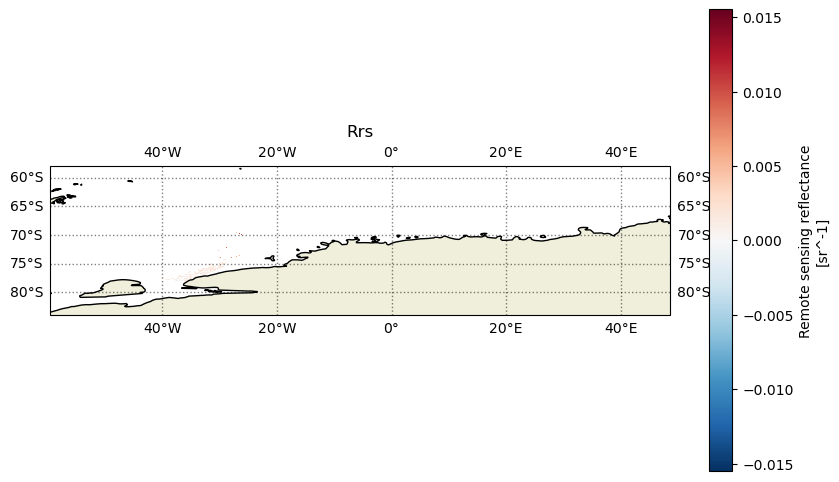

In [51]:
fig = plt.figure(figsize=(10,6))

# Create axes with Plate Carree projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Select wavelength
chosen_wl = dataset.Rrs.isel(wavelength_3d=100)

# Modify Rrs values
bad = chosen_wl.data <= -32767
chosen_wl.data[bad] = np.nan

# Creates gridded colored rectangles
# Plot using the axes we creates, geographic coordinates
chosen_wl.plot.pcolormesh(x='longitude', y='latitude', ax=ax, transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND)

gl = ax.gridlines(crs=ccrs.PlateCarree(), linewidth=1,
        color='black', alpha=0.5, linestyle=':', draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = True
gl.ylabels_right=False
gl.xlines = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'color': 'black'}
gl.ylabel_style = {'color': 'black'}
ax.set_title("Rrs")
plt.show()

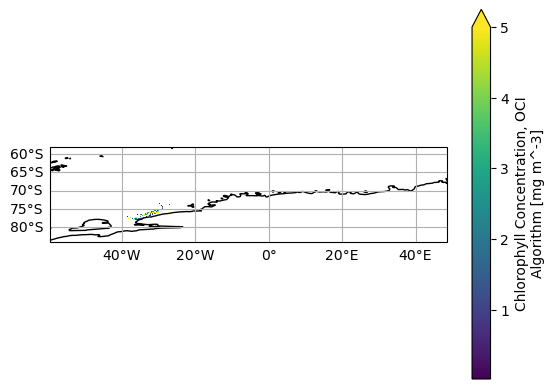

In [151]:
# Add coastlines and gridlines
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels={"left": "y", "bottom": "x"})
artist = dataset["chlor_a"].plot(x="longitude", y="latitude", cmap="viridis", vmax=5, ax=ax)